# Tutorial – Session 4

## Kontinuerte fordelinger I: Grundbegreber, PDF, CDF og integraler
### Teori, Python (SymPy) og WolframAlpha

I denne tutorial skifter vi gear fra den **diskrete** verden (hvor vi talte antal succeser eller fiaskoer) til den **kontinuerte** verden, hvor variabler kan antage *alle* mulige værdier i et interval (f.eks. tid, højde, vægt, temperatur).

Fordi der er uendeligt mange mulige decimaltal mellem to tal, er sandsynligheden for at ramme ét helt specifikt tal præcis nul: $P(X=a) = 0$. I stedet beregner vi sandsynligheden for, at et udfald lander i et **interval**. Dette gør vi ved at beregne **arealet** under en kurve ved hjælp af integralregning.

Vi arbejder systematisk med:

1. **PDF** (Probability Density Function) – Tæthedsfunktionen, der udgør kurven.
2. **CDF** (Cumulative Distribution Function) – Fordelingsfunktionen, der summerer arealet.
3. **Middelværdi og varians** – Beregnet med integraler i stedet for summer.
4. **Fraktiler og median** – At finde den $x$-værdi, der svarer til et bestemt areal.
5. **Den Kontinuerte Uniforme Fordeling** – Vores første standardiserede kontinuerte fordeling.

For at løse integraler og ligninger bruger vi biblioteket **SymPy** i Python (til symbolsk matematik) samt **WolframAlpha**.

---

## 1. Begreber: PDF og CDF

For en kontinuert stokastisk variabel $X$ bruger vi en **tæthedsfunktion** $f(x)$ i stedet for den diskrete PMF.

| Begreb | Forkortelse | Matematisk | Spørgsmål |
| :--- | :--- | :--- | :--- |
| **Probability Density Function** | **PDF** | $f(x)$ | Hvordan er "sandsynlighedsmassen" fordelt over talaksen? (Bemærk: $f(x)$ er *ikke* en sandsynlighed i sig selv, men en tæthed). |
| **Cumulative Distribution Function** | **CDF** | $F(x)=P(X\leq x)$ | Hvad er sandsynligheden for at udfaldet er $x$ eller mindre? (Dette er arealet under kurven op til $x$). |

**Tre vigtige regler for PDF'en $f(x)$:**
1. $f(x) \geq 0$ for alle $x$ (kurven må aldrig gå under x-aksen).
2. Det samlede areal under kurven er præcis 1: $\int_{-\infty}^{\infty} f(x)\,dx = 1$.
3. Sandsynligheden for et interval findes ved at integrere tæthedsfunktionen over dette interval: $P(a \leq X \leq b) = \int_a^b f(x)\,dx$.

**Sammenhængen mellem PDF og CDF:**
Fordelingsfunktionen (CDF) er simpelthen integralet af PDF'en fra starten (ofte $-\infty$) op til $x$:
$$F(x)=\int_{-\infty}^{x} f(t)\,dt$$

Det betyder også, at vi kan finde en intervalsandsynlighed på to måder:
$$P(a \leq X \leq b) = \int_a^b f(x)\,dx = F(b) - F(a)$$

---

## 2. Python Setup (SymPy)

Da vi skal arbejde med matematiske funktioner, symboler (som $x$) og integraler, bruger vi **SymPy**. Det tillader os at regne med brøker og symboler præcis ligesom vi ville gøre det på papir.

In [1]:
import sympy as sp
sp.init_printing() # Gør outputtet pænt at se på i Jupyter

# Vi opretter de matematiske symboler vi skal bruge
x, t, c = sp.symbols('x t c', real=True)

---

## 3. Gyldig PDF: Normalisering og ukendte konstanter

### 3.1 Teori

Ofte får vi opgivet en funktion med en ukendt konstant, og vi skal finde konstanten, så funktionen bliver en gyldig PDF.

Lad os antage, at vi har funktionen:
$$f(x)=\begin{cases}
cx, & 0 \leq x \leq 2\\
0, & \text{ellers}
\end{cases}$$

For at være en gyldig PDF skal det samlede areal være 1:
$$\int_0^2 cx\,dx = 1$$

Vi udregner integralet:
$$\left[ c \cdot \frac{x^2}{2} \right]_0^2 = c \cdot \frac{2^2}{2} - 0 = 2c$$

Vi sætter arealet lig 1:
$$2c = 1 \Rightarrow c = \frac{1}{2}$$

Dermed er vores gyldige PDF:
$$f(x)=\begin{cases}
\frac{x}{2}, & 0 \leq x \leq 2\\
0, & \text{ellers}
\end{cases}$$

### 3.2 Python (SymPy)

Vi kan lade SymPy løse ligningen for os. Her er et par vigtige SymPy-funktioner, vi bruger:
- `sp.integrate(funktion, (variabel, start, slut))` beregner det bestemte integral.
- `sp.Eq(venstre, højre)` opretter en matematisk ligning ($=$). Vi bruger `Eq` i stedet for `==`, da vi ønsker at definere en *symbolsk ligning*, der skal løses, og ikke bare teste om to sider er ens.
- `sp.solve(ligning, variabel)` løser ligningen for den valgte variabel. Den returnerer en *liste* med alle mulige løsninger. Da vi kun forventer én løsning, tager vi det første element med `[0]`.

In [2]:
# Sæt ligningen op: integrate(c*x fra 0 til 2) = 1
# sp.Eq(venstre_side, højre_side)
ligning = sp.Eq(sp.integrate(c*x, (x, 0, 2)), 1)

# Løs ligningen for c
c_value = sp.solve(ligning, c)[0]
print(f"c = {c_value}")

c = 1/2


Vi kan også bede SymPy verificere, at arealet nu er 1:

In [3]:
areal = sp.integrate(x/2, (x, 0, 2))
print(f"Samlet areal: {areal}")

Samlet areal: 1


### 3.3 WolframAlpha

I WolframAlpha kan vi skrive det næsten som vi tænker det:

```
solve(integrate(c*x, x, 0, 2)=1, c)
```

```
integrate(x/2, x, 0, 2)
```

---

## 4. Fra PDF til CDF (Stykkevis funktion)

### 4.1 Teori

For at finde den generelle formel for CDF'en $F(x)$, skal vi integrere PDF'en op til et generelt punkt $x$.

For vores PDF $f(x) = \frac{x}{2}$ (når $x$ er mellem 0 og 2):
$$F(x) = \int_0^x \frac{t}{2}\,dt = \left[ \frac{t^2}{4} \right]_0^x = \frac{x^2}{4}$$

*(Bemærk at vi bruger $t$ som "dummy"-variabel i integralet, så vi kan bruge $x$ som den øvre grænse).*

En CDF skal dog dække hele talaksen fra $-\infty$ til $\infty$, så den korrekte matematiske (og stykkevise) opskrivning er:
$$F(x)=\begin{cases}
0, & x < 0\\
\frac{x^2}{4}, & 0 \leq x \leq 2\\
1, & x > 2
\end{cases}$$

### 4.2 Python (SymPy)

Vi kan integrere og bygge en stykkevis funktion i SymPy.
- Funktionen `sp.Piecewise((udtryk1, betingelse1), (udtryk2, betingelse2), ...)` lader os definere en stykkevis funktion.
- SymPy tjekker betingelserne én efter én, fra venstre mod højre, og returnerer det udtryk, hvor betingelsen først er sand.
- Betingelsen `True` til sidst fungerer som "ellers" (else).

Indre CDF: x**2/4


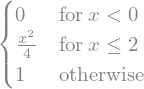

In [4]:
# Beregn det indre integral
F_inner = sp.simplify(sp.integrate(t/2, (t, 0, x)))
print(f"Indre CDF: {F_inner}")

# Opbyg den fulde stykkevise CDF
F = sp.Piecewise(
    (0, x < 0),
    (x**2/4, (x >= 0) & (x <= 2)),
    (1, True)
)
F

### 4.3 WolframAlpha

WolframAlpha kan integrere for os:
```
integrate(t/2, t, 0, x)
```

---

## 5. Sandsynligheder: Integralmetode vs. CDF-metode

### 5.1 Teori

Vi vil gerne finde sandsynligheden for, at $X$ falder mellem 0.5 og 1.5, altså $P(0.5 \leq X \leq 1.5)$.

Vi har to redskaber:

**1. Integral direkte fra PDF:**
Vi integrerer tæthedsfunktionen over det ønskede interval:
$$P(0.5 \leq X \leq 1.5) = \int_{0.5}^{1.5}\frac{x}{2}\,dx$$

**2. CDF-forskel:**
Hvis vi allerede kender CDF'en $F(x) = \frac{x^2}{4}$, kan vi bruge, at arealet på et interval er forskellen mellem de to akkumulerede arealer:
$$P(0.5 \leq X \leq 1.5) = F(1.5) - F(0.5) = \frac{1.5^2}{4} - \frac{0.5^2}{4}$$

Begge metoder skal give præcis samme resultat. Det er oftest hurtigst at bruge metoden, hvor man allerede har funktionen klar.

### 5.2 Python (SymPy)

Her bruger vi to nye funktioner:
- `sp.Rational(tæller, nævner)` opretter en eksakt brøk (f.eks. 1/2) i stedet for decimaltallet 0.5. Dette forhindrer afrundingsfejl, når vi regner symbolsk.
- `.subs(gammel, ny)` (substitution) erstatter et symbol med en specifik værdi. `cdf_expr.subs(x, sp.Rational(3,2))` betyder "sæt $x = 1.5$ ind i formlen for CDF'en".

In [5]:
# Metode 1: Integral (vi bruger brøker for præcision)
p_int = sp.integrate(x/2, (x, sp.Rational(1,2), sp.Rational(3,2)))

# Metode 2: CDF (indsæt 3/2 og 1/2 i F_inner funktionen og find forskellen)
cdf_expr = x**2/4
p_cdf = cdf_expr.subs(x, sp.Rational(3,2)) - cdf_expr.subs(x, sp.Rational(1,2))

print(f"Sandsynlighed via integral: {p_int}")
print(f"Sandsynlighed via CDF: {p_cdf}")

Sandsynlighed via integral: 1/2
Sandsynlighed via CDF: 1/2


*(Begge giver $1/2 = 0.5$)*

### 5.3 WolframAlpha

Integral-metoden:
```
integrate(x/2, x, 0.5, 1.5)
```

CDF-metoden:
```
(1.5^2 / 4) - (0.5^2 / 4)
```

---

## 6. Middelværdi og Varians for kontinuerte variable

### 6.1 Teori

I den diskrete verden beregnede vi forventningsværdi ved at gange hvert udfald med sin sandsynlighed og lægge dem sammen ($E[X] = \sum x \cdot P(x)$). 

I den kontinuerte verden udskifter vi summen med et integral og sandsynligheden med tæthedsfunktionen:
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x)\,dx$$

Ligesom før kan vi finde variansen ved hjælpeformlen:
$$\mathrm{Var}(X) = E[X^2] - (E[X])^2$$
hvor
$$E[X^2] = \int_{-\infty}^{\infty} x^2 \cdot f(x)\,dx$$

Lad os beregne det for vores funktion $f(x) = x/2$ på intervallet $[0,2]$:
$$E[X] = \int_0^2 x \cdot \left(\frac{x}{2}\right)\,dx = \int_0^2 \frac{x^2}{2}\,dx = \left[ \frac{x^3}{6} \right]_0^2 = \frac{8}{6} = \frac{4}{3}$$

$$E[X^2] = \int_0^2 x^2 \cdot \left(\frac{x}{2}\right)\,dx = \int_0^2 \frac{x^3}{2}\,dx = \left[ \frac{x^4}{8} \right]_0^2 = \frac{16}{8} = 2$$

$$\mathrm{Var}(X) = 2 - \left(\frac{4}{3}\right)^2 = 2 - \frac{16}{9} = \frac{18}{9} - \frac{16}{9} = \frac{2}{9}$$

### 6.2 Python (SymPy)

SymPy gør det nemt at håndtere brøkerne uden afrundingsfejl:

In [6]:
# E[X]
EX = sp.integrate(x * (x/2), (x, 0, 2))

# E[X^2]
EX2 = sp.integrate(x**2 * (x/2), (x, 0, 2))

# Varians
VarX = sp.simplify(EX2 - EX**2)

print(f"E[X] = {EX}")
print(f"E[X^2] = {EX2}")
print(f"Var(X) = {VarX}")

E[X] = 4/3
E[X^2] = 2
Var(X) = 2/9


### 6.3 WolframAlpha

Middelværdi $E[X]$:
```
integrate(x * (x/2), x, 0, 2)
```
Forventet værdi af $X$ kvadreret $E[X^2]$:
```
integrate(x^2 * (x/2), x, 0, 2)
```
Varians $\mathrm{Var}(X) = E[X^2] - (E[X])^2$:
```
integrate(x^2*(x/2), x, 0, 2) - (integrate(x*(x/2), x, 0, 2))^2
```

---

## 7. Fraktiler og Median

### 7.1 Teori

En **fraktil** (eller percentil) besvarer spørgsmålet: "For hvilken værdi af $x$ er det akkumulerede areal (sandsynligheden) præcis $p$?"

Matematisk betyder det at vi skal løse ligningen:
$$F(x) = p$$

**Medianen** er den midterste værdi, dvs. 50%-fraktilen ($p=0.5$). 
For at finde medianen $m$ i vores eksempel løser vi:
$$F(m) = 0.5 \Rightarrow \frac{m^2}{4} = \frac{1}{2} \Rightarrow m^2 = 2 \Rightarrow m = \sqrt{2} \approx 1.414$$
*(Vi forkaster den negative løsning $m = -\sqrt{2}$, da vores PDF kun er defineret for $0 \leq x \leq 2$)*.

### 7.2 Python (SymPy)

In [7]:
# Vi definerer symbolet m
m = sp.symbols('m', real=True)

# Løs ligningen F(m) = 0.5
loesninger = sp.solve(sp.Eq(m**2/4, sp.Rational(1,2)), m)

print(f"Matematiske løsninger for medianen: {loesninger}")
# Vi kan evaluere til decimaltal:
print(f"Gyldig løsning som decimal: {loesninger[1].evalf():.4f}")

Matematiske løsninger for medianen: [-sqrt(2), sqrt(2)]
Gyldig løsning som decimal: 1.4142


### 7.3 WolframAlpha

```
solve(x^2 / 4 = 0.5, x)
```

---

## 8. Den Kontinuerte Uniforme Fordeling

### 8.1 Teori

Den simpleste kontinuerte fordeling er **den kontinuerte uniforme fordeling**. Her er al sandsynlighed jævnt fordelt mellem en nedre grænse $a$ og en øvre grænse $b$. 
Den skrives som $X \sim U(a,b)$.

*Eksempel: En bus ankommer et tilfældigt sted mellem kl. 10:00 og 10:10. Ventetiden $X$ (i minutter) er uniformt fordelt mellem 0 og 10, altså $X \sim U(0, 10)$.*

**Parametre:**
- $a$: nedre grænse
- $b$: øvre grænse

**Tæthedsfunktion (PDF):**
Højden af kassen skal være sådan, at arealet (bredde $\times$ højde) bliver 1. Bredden er $(b-a)$, så højden (PDF'en) er:
$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

**Fordelingsfunktion (CDF):**
$$F(x) = \frac{x-a}{b-a}, \quad a \leq x \leq b$$

**Middelværdi og Varians:**
$$E[X] = \frac{a+b}{2}, \quad \mathrm{Var}(X) = \frac{(b-a)^2}{12}$$

### 8.2 Python (SciPy)

For standardfordelinger skifter vi fra SymPy tilbage til **SciPy** (ligesom vi brugte `binom` og `poisson` tidligere). Den kontinuerte uniforme fordeling hedder `uniform` i SciPy.

Syntaksen er lidt speciel: Vi skal angive startpunkt `loc` ($a$) og bredden `scale` ($b-a$).
For $U(0, 10)$ er `loc=0` og `scale=10`. For $U(5, 15)$ er `loc=5` og `scale=10`.

In [8]:
from scipy.stats import uniform

# Vi betragter en ventetid X ~ U(0, 10)
a = 0
b = 10
bredde = b - a

# Hvad er sandsynligheden for at vente mindre end 3 minutter? P(X <= 3)
p_mindre_end_3 = uniform.cdf(3, loc=a, scale=bredde)
print(f"P(X <= 3) = {p_mindre_end_3}")

# Hvad er sandsynligheden for at vente mellem 4 og 7 minutter? P(4 <= X <= 7)
p_mellem_4_og_7 = uniform.cdf(7, loc=a, scale=bredde) - uniform.cdf(4, loc=a, scale=bredde)
print(f"P(4 <= X <= 7) = {p_mellem_4_og_7}")

# Hvad er middelværdien?
print(f"E[X] = {uniform.mean(loc=a, scale=bredde)}")

P(X <= 3) = 0.3
P(4 <= X <= 7) = 0.29999999999999993
E[X] = 5.0


### 8.3 WolframAlpha

WolframAlpha forstår fordelingen direkte:

- **CDF $P(X \leq 3)$ for $U(0,10)$**
```
P(X<=3) UniformDistribution(0, 10)
```

- **Middelværdi**
```
mean UniformDistribution(0, 10)
```

---

## 9. Opsummering – Hvad du nu skal kunne

Efter denne tutorial og session kan du:

- Forstå forskellen på den diskrete verden (hvor vi kan udpege sandsynligheden for et specifikt tal) og den kontinuerte verden (hvor vi måler arealer og intervaller).
- Skelne mellem **PDF** $f(x)$ (højden af kurven) og **CDF** $F(x)$ (det akkumulerede areal).
- Kontrollere om en funktion er en gyldig PDF ved at integrere den fra $-\infty$ til $\infty$ (skal give 1).
- Beregne interval-sandsynligheder $P(a \leq X \leq b)$ ved hjælp af enten integration af PDF'en eller som $F(b) - F(a)$.
- Udregne forventningsværdi og varians ved at integrere henholdsvis $x \cdot f(x)$ og $x^2 \cdot f(x)$.
- Finde en fraktil (f.eks. medianen) ved at løse ligningen $F(x) = p$.
- Arbejde med den **Kontinuerte Uniforme Fordeling**, både formelmæssigt og via SciPy (`uniform`) eller WolframAlpha.